# XGBoost Tuning + SHAP

In [4]:
!pip install optuna shap xgboost imbalanced-learn --quiet

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')
print(" All imports done")

 All imports done


In [6]:

#  Load + Clean + Feature Engineering
df = pd.read_csv('cs-training.csv', index_col=0)

df.columns = [
    'target', 'util_rate', 'age', 'late_30_59',
    'debt_ratio', 'monthly_income', 'open_credits',
    'late_90', 'real_estate_loans', 'late_60_89', 'dependents'
]

df['monthly_income'].fillna(df['monthly_income'].median(), inplace=True)
df['dependents'].fillna(df['dependents'].median(), inplace=True)
df = df[df['age'] > 0]
df['util_rate'] = df['util_rate'].clip(upper=1.0)

# Feature engineering
df['debt_to_income']      = np.where(df['monthly_income'] > 0,
                                df['debt_ratio'] / (df['monthly_income'] + 1), 0)
df['total_late']          = df['late_30_59'] + df['late_60_89'] + df['late_90']
df['has_late_history']    = (df['total_late'] > 0).astype(int)
df['income_per_dependent']= np.where(df['dependents'] > 0,
                                df['monthly_income'] / df['dependents'],
                                df['monthly_income'])
df['high_util']           = (df['util_rate'] > 0.7).astype(int)

feature_cols = [
    'util_rate', 'age', 'late_30_59', 'debt_ratio',
    'monthly_income', 'open_credits', 'late_90',
    'real_estate_loans', 'late_60_89', 'dependents',
    'debt_to_income', 'total_late', 'has_late_history',
    'income_per_dependent', 'high_util'
]

X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"✓ Data ready — Train: {X_train_sm.shape} | Test: {X_test.shape}")

✓ Data ready — Train: (223956, 15) | Test: (30000, 15)


In [7]:

# Optuna Hyperparameter Tuning
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'eval_metric'       : 'auc',
        'random_state'      : 42,
        'n_jobs'            : -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(
        model, X_train_sm, y_train_sm,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ Best AUC (CV): {study.best_value:.4f}")
print(f"✓ Best params:\n{study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


✓ Best AUC (CV): 0.9663
✓ Best params:
{'n_estimators': 527, 'max_depth': 8, 'learning_rate': 0.07838855315902707, 'subsample': 0.9688138373284421, 'colsample_bytree': 0.6901408489764067, 'min_child_weight': 2, 'reg_alpha': 0.01930598377328773, 'reg_lambda': 0.0010072485955874534}


In [8]:

#  Train final model
best_params = study.best_params
best_params.update({'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1})

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

final_proba = final_model.predict_proba(X_test)[:, 1]
final_auc   = roc_auc_score(y_test, final_proba)

print(f"✓ Final model ROC-AUC on test: {final_auc:.4f}")

✓ Final model ROC-AUC on test: 0.7987


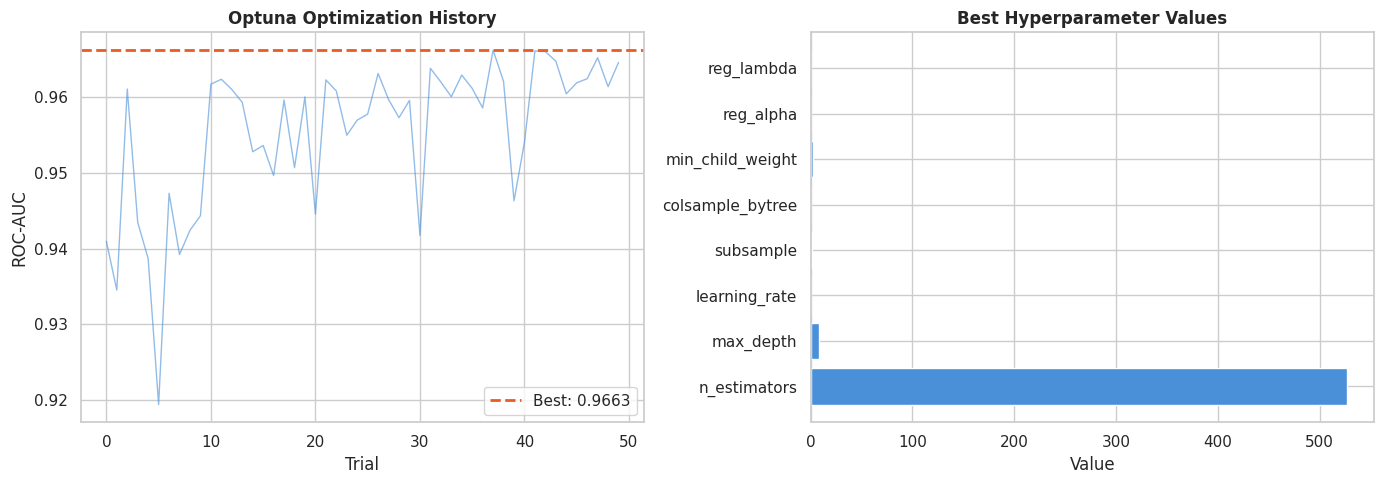

In [9]:

# Optuna visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials_auc = [t.value for t in study.trials]
axes[0].plot(trials_auc, color='#4A90D9', alpha=0.6, linewidth=1)
axes[0].axhline(study.best_value, color='#E85D24',
                linestyle='--', linewidth=2, label=f'Best: {study.best_value:.4f}')
axes[0].set_title('Optuna Optimization History', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()

# Parameter importance (manual)
param_names  = list(study.best_params.keys())
param_values = [abs(study.best_params[k]) if isinstance(study.best_params[k], float)
                else study.best_params[k] for k in param_names]

axes[1].barh(param_names, param_values, color='#4A90D9')
axes[1].set_title('Best Hyperparameter Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.savefig('optuna_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:

explainer  = shap.TreeExplainer(final_model)
sample_idx  = X_test.sample(500, random_state=42).index
X_sample    = X_test.loc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print(f"✓ SHAP values computed — shape: {shap_values.shape}")

✓ SHAP values computed — shape: (500, 15)


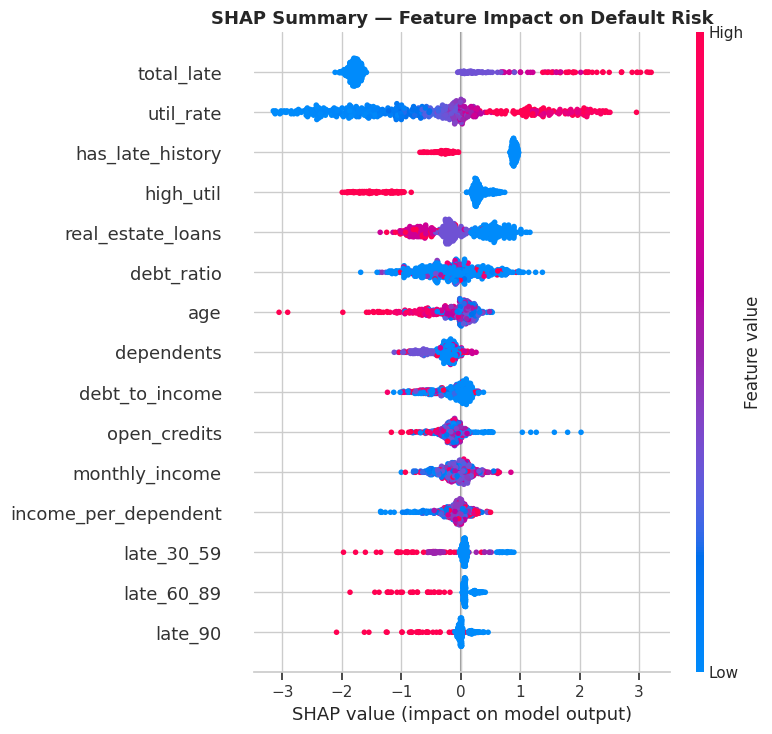

In [11]:

# SHAP Summary Plot
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_cols,
    plot_type='dot',
    show=False,
    max_display=15
)

plt.title('SHAP Summary — Feature Impact on Default Risk',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

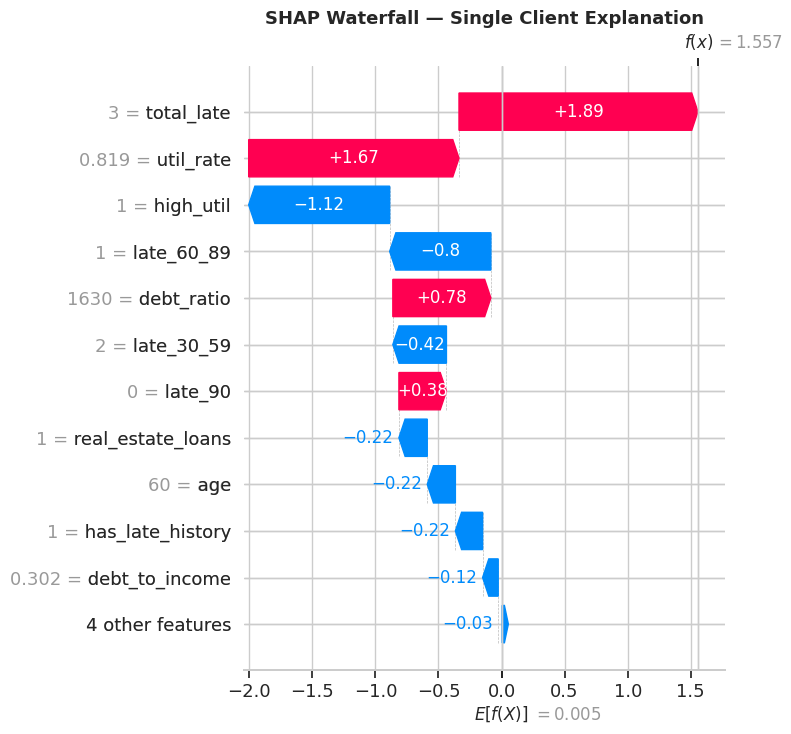

Client risk score: 82.59%


In [12]:

high_risk_idx = np.where(
    final_model.predict_proba(X_sample)[:, 1] > 0.6
)[0]

if len(high_risk_idx) == 0:
    client_idx = 0
else:
    client_idx = high_risk_idx[0]

client_data  = X_sample.iloc[[client_idx]]
client_shap  = explainer(client_data)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(client_shap[0], max_display=12, show=False)
plt.title('SHAP Waterfall — Single Client Explanation',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

risk_score = final_model.predict_proba(client_data)[:, 1][0]
print(f"Client risk score: {risk_score:.2%}")

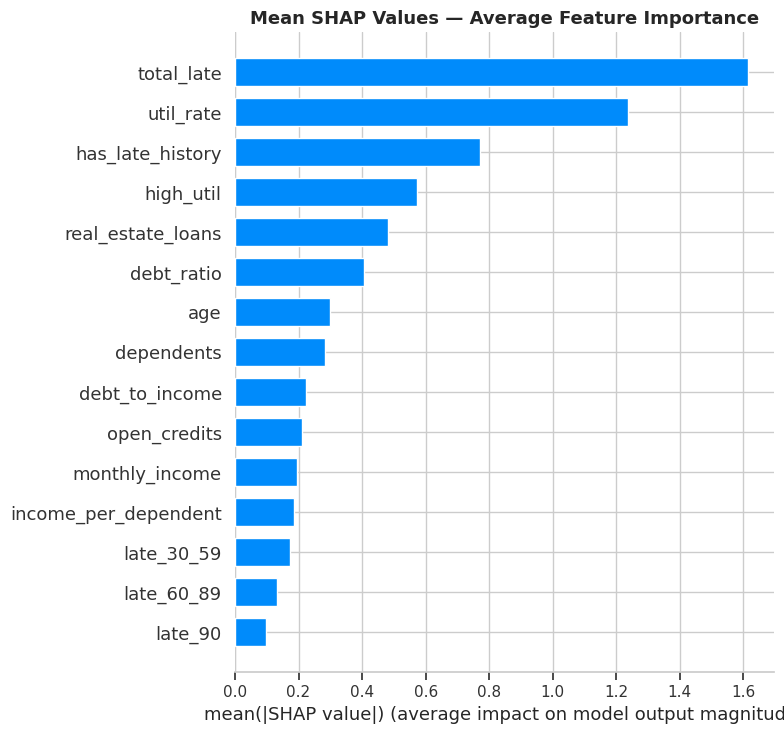

In [13]:

#  SHAP Bar Plot (mean impact)
plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_cols,
    plot_type='bar',
    show=False,
    max_display=15
)

plt.title('Mean SHAP Values — Average Feature Importance',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Top feature: total_late


<Figure size 800x500 with 0 Axes>

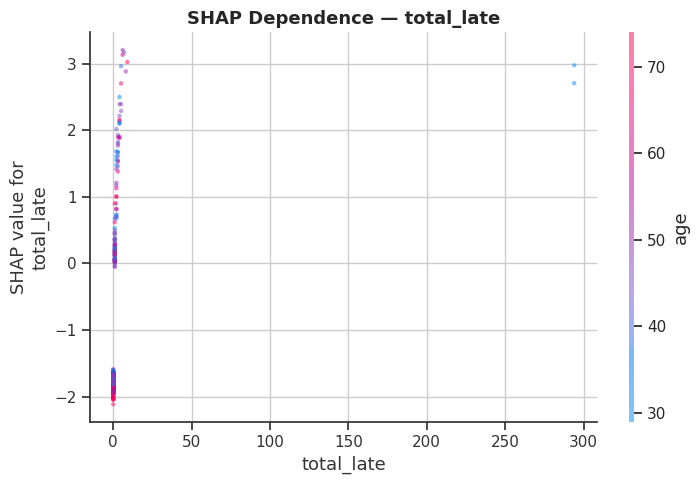

In [14]:

#  SHAP Dependence Plot
top_feature = feature_cols[np.abs(shap_values).mean(0).argmax()]
print(f"Top feature: {top_feature}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    shap_values,
    X_sample,
    feature_names=feature_cols,
    show=False,
    dot_size=10,
    alpha=0.5
)
plt.title(f'SHAP Dependence — {top_feature}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:

from google.colab import files


test_df = pd.read_csv('cs-test.csv', index_col=0)

# Drop the 'SeriousDlqin2yrs' column as it's not a feature in the test set
test_df = test_df.drop('SeriousDlqin2yrs', axis=1)

test_df.columns = [
    'util_rate', 'age', 'late_30_59', 'debt_ratio',
    'monthly_income', 'open_credits', 'late_90',
    'real_estate_loans', 'late_60_89', 'dependents'
]

test_df['monthly_income'].fillna(test_df['monthly_income'].median(), inplace=True)
test_df['dependents'].fillna(test_df['dependents'].median(), inplace=True)
test_df = test_df[test_df['age'] > 0].copy()
test_df['util_rate'] = test_df['util_rate'].clip(upper=1.0)

test_df['debt_to_income']       = np.where(test_df['monthly_income'] > 0,
                                    test_df['debt_ratio'] / (test_df['monthly_income'] + 1), 0)
test_df['total_late']           = test_df['late_30_59'] + test_df['late_60_89'] + test_df['late_90']
test_df['has_late_history']     = (test_df['total_late'] > 0).astype(int)
test_df['income_per_dependent'] = np.where(test_df['dependents'] > 0,
                                    test_df['monthly_income'] / test_df['dependents'],
                                    test_df['monthly_income'])
test_df['high_util']            = (test_df['util_rate'] > 0.7).astype(int)

test_preds = final_model.predict_proba(test_df[feature_cols])[:, 1]

submission = pd.DataFrame({
    'Id'                  : test_df.index,
    'Probability'         : test_preds
})

submission.to_csv('submission.csv', index=False)
print(f"✓ Submission ready — {len(submission)} rows")
print(submission.head())
files.download('submission.csv')


✓ Submission ready — 101503 rows
   Id  Probability
0   1     0.151646
1   2     0.058269
2   3     0.112621
3   4     0.204770
4   5     0.197344


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:

# Save final model + artifacts
import pickle, json

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

with open('shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("✓ final_model.pkl")
print("✓ feature_cols.json")
print("✓ shap_explainer.pkl")
print(f"\n Final Test ROC-AUC: {final_auc:.4f}")

files.download('final_model.pkl')
files.download('feature_cols.json')
files.download('shap_explainer.pkl')

✓ final_model.pkl
✓ feature_cols.json
✓ shap_explainer.pkl

 Final Test ROC-AUC: 0.7987


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import json

metrics = {
    "roc_auc"        : round(final_auc, 4),
    "cv_auc_mean"    : round(study.best_value, 4),
    "training_samples": int(X_train_sm.shape[0]),
    "n_features"     : len(feature_cols),
    "model_name"     : "XGBoost",
    "dataset"        : "Give Me Some Credit"
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(metrics)
files.download('model_metrics.json')

{'roc_auc': np.float64(0.7987), 'cv_auc_mean': 0.9663, 'training_samples': 223956, 'n_features': 15, 'model_name': 'XGBoost', 'dataset': 'Give Me Some Credit'}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from sklearn.metrics import roc_curve, confusion_matrix
import json

# ROC curve data
fpr, tpr, _ = roc_curve(y_test, final_proba)

sample_step = max(1, len(fpr) // 200)
fpr_sampled = fpr[::sample_step].tolist()
tpr_sampled = tpr[::sample_step].tolist()


cm = confusion_matrix(y_test, final_model.predict(X_test))

metrics = {
    "roc_auc"          : round(final_auc, 4),
    "cv_auc_mean"      : round(study.best_value, 4),
    "training_samples" : int(X_train_sm.shape[0]),
    "test_samples"     : int(X_test.shape[0]),
    "n_features"       : len(feature_cols),
    "model_name"       : "XGBoost",
    "dataset"          : "Give Me Some Credit",
    "roc_fpr"          : fpr_sampled,
    "roc_tpr"          : tpr_sampled,
    "confusion_matrix" : cm.tolist(),
    "default_rate"     : round(float(y_test.mean()), 4)
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(" Saved")
print(f"ROC AUC: {metrics['roc_auc']}")
print(f"CM: {cm}")
files.download('model_metrics.json')

✓ Saved!
ROC AUC: 0.7987
CM: [[25720  2275]
 [ 1193   812]]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>